In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [41]:
def primitiva_v1(f,x):
    integral , h = np.zeros_like(f) , x[1]-x[0]
    integral[0] = 0
    for i in range(1,len(x)-4):
        integral[i] += integral[i-1] + (23*f[i] + 26*f[i+1] - 4*f[i+2] + 6*f[i+3] - 3*f[i+4])*h/48
    #integral[-1] = integral[-2] + 0.5*(17*f[-1] + 7*f[-2] + f[-3] - f[-4])
    return integral

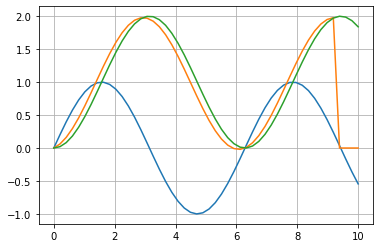

In [48]:
x = np.linspace(0,10)
y = np.sin(x)
int_y = primitiva_v1(y,x)
Y = 1-np.cos(x)
plt.plot(x,y)
plt.plot(x,int_y)
plt.plot(x,Y)
plt.grid()
plt.show()

In [50]:
def primitiva(f,x):
    integral , h = np.zeros_like(f) , x[1]-x[0]
    integral[0] = 0
    for i in range(1,len(x)-4):
        integral[i] += integral[i-1] + (23*f[i] + 26*f[i+1] - 4*f[i+2] + 6*f[i+3] - 3*f[i+4])*h/48
    for i in range(-3,1):
        integral[i-1] = integral[i-2]+ (
            23*f[i-1] + 26*f[i-2] - 4*f[i-3] + 6*f[i-4] - 3*f[i-5])*h/48
    return integral

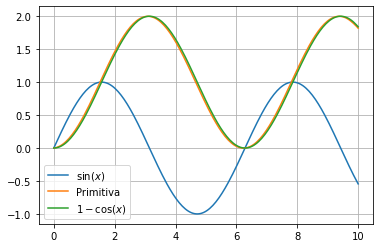

In [54]:
x = np.linspace(0,10,200)
y = np.sin(x)
int_y = primitiva(y,x)
Y = 1-np.cos(x)
plt.plot(x,y,label=r'$\sin(x)$')
plt.plot(x,int_y,label=r'Primitiva')
plt.plot(x,Y,label=r'$1-\cos(x)$')
plt.grid(),plt.legend()
plt.show()

In [75]:
def primitiva_sim(f,x,ci=0):
    integral , h = np.zeros_like(f) , x[1]-x[0]
    integral[0] = 0.5*(17*f[0] + 7*f[1] + f[2] - f[3])
    for i in range(1,len(x)-1):
        integral[i] += integral[i-1] + (f[i+1] + 22*f[i] + f[i-1])
    integral[-1] = integral[-2] + 0.5*(17*f[-1] + 7*f[-2] + f[-3] - f[-4])
    return integral*h/24 + ci

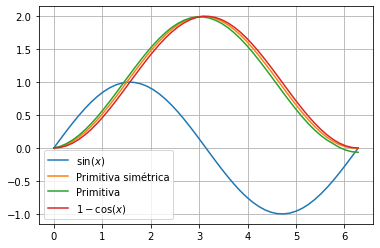

In [76]:
x = np.linspace(0,2*np.pi)
y = np.sin(x)
int_y_sim = primitiva_sim(y,x)
int_y = primitiva(y,x)
Y = 1-np.cos(x)
plt.plot(x,y,label=r'$\sin(x)$')
plt.plot(x,int_y_sim,label=r'Primitiva simétrica')
plt.plot(x,int_y,label=r'Primitiva')
plt.plot(x,Y,label=r'$1-\cos(x)$')
plt.grid(),plt.legend()
plt.show()

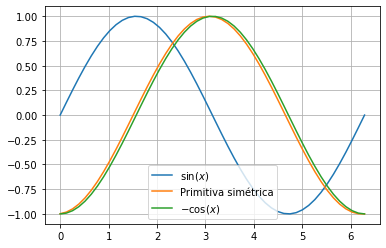

In [81]:
x = np.linspace(0,2*np.pi)
y = np.sin(x)
int_y_sim = primitiva_sim(y,x,ci=-1)
Y = -np.cos(x)
plt.plot(x,y,label=r'$\sin(x)$')
plt.plot(x,int_y_sim,label=r'Primitiva simétrica')
plt.plot(x,Y,label=r'$-\cos(x)$')
plt.grid(),plt.legend()
plt.show()